# S13 · A 20M LLM trained for 50M tokens, with and without reversibility

1. **Baseline**: standard pre-LN GPT, 20.0M params, fixed batch 64 × 512 tokens, 50M tokens.
2. **Reversible**: same model, same batch, same data order, with activations rebuilt in the
   backward pass. Four integrators are tried first (RevNet coupling, midpoint, leapfrog,
   Euler + fixed-point inversion) and the best one that is trustworthy is kept.
3. **Reversible at maximum batch**: same variant, largest batch that fits on this GPU.

Reported: final train/val loss, tokens/s, peak GPU memory, plus the variant sweep, gradient
fidelity vs autograd, and max-batch probes for baseline / activation checkpointing /
reversible.

**Runtime → Change runtime type → GPU.** On a T4 expect roughly 1.5–2.5 h for everything;
on an L4/A100 well under an hour. Every stage writes JSON and skips finished work, so
after a disconnect just run all cells again (mount Drive below to survive a VM reset).

In [ ]:
!nvidia-smi --query-gpu=name,memory.total --format=csv
import torch; print(torch.__version__, torch.cuda.is_available())

name, memory.total [MiB]
Tesla T4, 15360 MiB
2.11.0+cu128 True


Data and runs go to Google Drive (approve the mount pop-up), so a disconnect or runtime reset loses nothing. Set `USE_DRIVE = False` to keep everything on the VM instead.

In [ ]:
USE_DRIVE = True
ROOT = "/content/s13"
if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = "/content/drive/MyDrive/s13_reversible"
import os
os.makedirs(ROOT, exist_ok=True)
os.makedirs("/content/s13_code/revlm", exist_ok=True)
os.makedirs("/content/s13_code/tests", exist_ok=True)
%cd /content/s13_code
!pip -q install datasets tokenizers
import subprocess, sys

def stage(name):
    # A failing `!python ...` does not stop "Run all"; this does, so the first error is
    # the one you see instead of a cascade of empty stages.
    p = subprocess.Popen([sys.executable, "-u", "run_all.py", "--root", ROOT, "--stage", name],
                         stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1,
                         env={**os.environ, "PYTHONUNBUFFERED": "1"})
    for line in p.stdout:  # relay live; child output is otherwise invisible in Colab
        print(line, end="", flush=True)
    if p.wait() != 0:
        raise RuntimeError(f"stage {name!r} failed (exit {p.returncode}); see output above")

Mounted at /content/drive
/content/s13_code


## Source
Generated from the repo; the reversible machinery is in `revlm/reversible.py`.

In [ ]:
%%writefile revlm/__init__.py
import os

# Must be set before the first CUDA allocation. The max-batch probe always ran with it; the
# training runs did not, so a batch that fit in a 3-step probe fragmented its way to OOM in
# the real run (run 3, first Colab attempt). Every entry point imports this package first.
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

Writing revlm/__init__.py


In [ ]:
%%writefile revlm/reversible.py
"""Reversible residual stacks: activations are rebuilt in the backward pass, not stored.

A normal residual stack x_{n+1} = x_n + f_n(x_n) is a forward-Euler integrator. Autograd
must keep every x_n (and every intermediate inside f_n) alive until backward reaches that
layer, so activation memory grows linearly with depth.

If instead each layer is an *invertible* map of a small state, backward can walk the stack
from the top, reconstructing layer n's input from its output, recomputing that one layer
with grad enabled, and backpropagating through it before moving down. Only the final
state is ever stored, so activation memory is O(1) in depth. The price is one extra
forward pass per layer (~4/3 of normal training compute).

Every variant below is a map on a tuple `state`, with:

    init(x)            embedding output -> initial state
    step(blk, s)       one layer forward                    (used by forward, no grad)
    back(blk, s, g)    given the layer's OUTPUT state and the grads w.r.t. it, return the
                       layer's INPUT state and the grads w.r.t. it; parameter grads are
                       accumulated into .grad as a side effect
    readout(s)         final state -> hidden vector fed to the LM head

Each `back` recomputes the layer's sublayers exactly once with grad enabled and reuses
that single recompute both to invert the layer and to backpropagate through it.

`blk.F` is the attention sublayer, `blk.G` the MLP sublayer and `blk.f(x) = F(x) +
G(x + F(x))`, the whole pre-LN block written as a residual update (x + blk.f(x) is
exactly an ordinary transformer block).
"""
from __future__ import annotations

import torch
from torch.amp import custom_bwd, custom_fwd


def _vjp(out: torch.Tensor, grad: torch.Tensor) -> None:
    # Autocast makes sublayer outputs bf16/fp16 while the residual state is fp32. Ordinary
    # autograd casts the incoming fp32 grad down to the branch dtype at the add; do the same.
    torch.autograd.backward(out, grad.to(out.dtype))


def _leaf(t: torch.Tensor) -> torch.Tensor:
    return t.detach().requires_grad_(True)


class RevNet:
    """Additive coupling (Gomez et al. 2017; Reformer). Two streams, exactly invertible:

        a' = a + F(b)            b  = b' - G(a')
        b' = b + G(a')     <=>   a  = a' - F(b)

    Numerically this is symplectic Euler on a split state, which is why it is also called
    the "Hamiltonian" or "leapfrog-coupled" reversible block. Readout averages the streams.
    """

    name, exact = "revnet", True

    def init(self, x):
        return (x, x)

    def step(self, blk, s):
        a, b = s
        a = a + blk.F(b)
        b = b + blk.G(a)
        return (a, b)

    def readout(self, s):
        return 0.5 * (s[0] + s[1])

    def back(self, blk, s, g):
        a1, b1 = s
        ga1, gb1 = g
        with torch.enable_grad():
            a1_ = _leaf(a1)
            go = blk.G(a1_)
            _vjp(go, gb1)
        with torch.no_grad():
            b0 = b1 - go
            ga = ga1 + a1_.grad  # total grad w.r.t. a' == grad w.r.t. a
        with torch.enable_grad():
            b0_ = _leaf(b0)
            fo = blk.F(b0_)
            _vjp(fo, ga)
        with torch.no_grad():
            a0 = a1 - fo
            gb = gb1 + b0_.grad
        return (a0, b0), (ga, gb)


class Midpoint:
    """Explicit midpoint / two-step leapfrog (Chang et al. 2018, "Midpoint network"):

        x_{n+1} = x_{n-1} + 2h f(x_n),   h = 1/2   =>   x_{n-1} = x_{n+1} - 2h f(x_n)

    State is the pair (x_{n-1}, x_n). With h = 1/2 each update has the same magnitude as an
    ordinary residual block. Known weakness: even and odd layers only talk to each other
    through f, and the scheme has a parasitic oscillating mode.
    """

    name, exact = "midpoint", True

    def init(self, x):
        return (x, x)

    def step(self, blk, s):
        u, v = s
        return (v, u + blk.f(v))

    def readout(self, s):
        return s[1]

    def back(self, blk, s, g):
        p, q = s  # p = x_n, q = x_{n+1}
        gp, gq = g
        with torch.enable_grad():
            p_ = _leaf(p)
            fo = blk.f(p_)
            _vjp(fo, gq)
        with torch.no_grad():
            u = q - fo
            gv = gp + p_.grad
        return (u, p), (gq, gv)


class Leapfrog:
    """Second-order leapfrog (Chang et al. 2018, "Leapfrog network"), h = 1:

        x_{n+1} = 2 x_n - x_{n-1} + h^2 f(x_n)   =>   x_{n-1} = 2 x_n - x_{n+1} + h^2 f(x_n)

    f acts as an acceleration: the difference x_n - x_{n-1} is a velocity that keeps
    accumulating, so the residual stream can grow quadratically with depth.
    """

    name, exact = "leapfrog", True

    def init(self, x):
        return (x, x)

    def step(self, blk, s):
        u, v = s
        return (v, 2 * v - u + blk.f(v))

    def readout(self, s):
        return s[1]

    def back(self, blk, s, g):
        p, q = s
        gp, gq = g
        with torch.enable_grad():
            p_ = _leaf(p)
            fo = blk.f(p_)
            _vjp(fo, gq)
        with torch.no_grad():
            u = 2 * p - q + fo
            gv = gp + 2 * gq + p_.grad
        return (u, p), (-gq, gv)


class Euler:
    """The ordinary residual stack, x_{n+1} = x_n + f(x_n), made "reversible" by solving

        x_n = x_{n+1} - f(x_n)

    with `iters` fixed-point iterations. This is NOT exact: it converges only where f is a
    contraction, and costs `iters` extra forwards per layer. Its forward pass is
    bit-identical to the standard model; only the gradients are approximate. The largest
    relative inversion residual |z + f(z) - x_{n+1}| / |x_{n+1}| seen since the last read is
    kept in `max_resid`.
    """

    name, exact = "euler", False

    def __init__(self, iters: int = 6):
        self.iters = iters
        self.max_resid = None

    def init(self, x):
        return (x,)

    def step(self, blk, s):
        return (s[0] + blk.f(s[0]),)

    def readout(self, s):
        return s[0]

    def back(self, blk, s, g):
        (y,), (gy,) = s, g
        with torch.no_grad():
            z = y
            for _ in range(self.iters):
                z = y - blk.f(z)
        with torch.enable_grad():
            z_ = _leaf(z)
            fo = blk.f(z_)
            _vjp(fo, gy)
        with torch.no_grad():
            r = (z + fo - y).norm() / y.norm().clamp_min(1e-12)
            self.max_resid = r if self.max_resid is None else torch.maximum(self.max_resid, r)
        return (z,), (gy + z_.grad,)

    def pop_resid(self) -> float | None:
        r, self.max_resid = self.max_resid, None
        return None if r is None else float(r)


def make_variant(mode: str, euler_iters: int = 6):
    if mode == "revnet":
        return RevNet()
    if mode == "midpoint":
        return Midpoint()
    if mode == "leapfrog":
        return Leapfrog()
    if mode in ("euler", "standard", "ckpt"):
        return Euler(euler_iters)
    raise ValueError(mode)


class RevStack(torch.autograd.Function):
    """Runs `blocks` under no_grad and saves only the final state; backward reconstructs.

    Parameters are deliberately not inputs to the Function: their grads are accumulated
    by the per-layer backward calls inside `back`, exactly as reentrant checkpointing does.
    custom_fwd/custom_bwd make the backward recompute run under the same autocast state
    as the forward, so the recomputed f is the same f.
    """

    @staticmethod
    @custom_fwd(device_type="cuda")
    def forward(ctx, blocks, variant, *state):
        inputs = state
        with torch.no_grad():
            for blk in blocks:
                state = variant.step(blk, state)
        # an output that is literally an input tensor (possible with 1 layer) confuses
        # autograd's bookkeeping; hand back a copy instead
        state = tuple(s.clone() if any(s is i for i in inputs) else s for s in state)
        ctx.blocks, ctx.variant = blocks, variant
        ctx.save_for_backward(*state)
        return state

    @staticmethod
    @custom_bwd(device_type="cuda")
    def backward(ctx, *grads):
        state = tuple(t.detach() for t in ctx.saved_tensors)
        for blk in reversed(ctx.blocks):
            state, grads = ctx.variant.back(blk, state, grads)
        return (None, None, *grads)

Writing revlm/reversible.py


In [ ]:
%%writefile revlm/model.py
"""A 20.0M-parameter GPT whose residual trunk can be swapped between six integrators.

    standard  x_{n+1} = x_n + f(x_n), plain autograd (stores everything)
    ckpt      same forward, activation checkpointing per block (stores one tensor per layer)
    euler     same forward, backward inverts each block by fixed-point iteration (approx.)
    revnet    two-stream additive coupling, exactly invertible
    midpoint  x_{n+1} = x_{n-1} + 2h f(x_n), exactly invertible
    leapfrog  x_{n+1} = 2x_n - x_{n-1} + h^2 f(x_n), exactly invertible

All six have the same parameters (same blocks, same shapes), so parameter count, optimizer
memory and FLOPs per forward are identical and only activation memory and backward cost
differ.

The LM head + cross-entropy is computed in checkpointed row chunks in every mode. At large
batch the (B*T, vocab) logits would otherwise be the biggest tensor in the program and
would hide exactly the activation savings this repo is trying to measure.
"""
from __future__ import annotations

import math
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.checkpoint import checkpoint

from .reversible import RevStack, make_variant

MODES = ("standard", "ckpt", "euler", "revnet", "midpoint", "leapfrog")
REVERSIBLE = ("euler", "revnet", "midpoint", "leapfrog")


@dataclass
class Config:
    vocab_size: int = 8192
    block_size: int = 512
    n_layer: int = 14
    n_head: int = 5
    n_embd: int = 320
    mode: str = "standard"
    euler_iters: int = 6
    ce_chunk: int = 8192  # rows of B*T per checkpointed LM-head/CE chunk


class Attention(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.n_head = cfg.n_head
        self.qkv = nn.Linear(cfg.n_embd, 3 * cfg.n_embd, bias=False)
        self.proj = nn.Linear(cfg.n_embd, cfg.n_embd, bias=False)

    def forward(self, x):
        B, T, C = x.shape
        H = self.n_head
        q, k, v = self.qkv(x).split(C, dim=2)
        q, k, v = (t.view(B, T, H, C // H).transpose(1, 2) for t in (q, k, v))
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        return self.proj(y.transpose(1, 2).reshape(B, T, C))


class MLP(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.fc = nn.Linear(cfg.n_embd, 4 * cfg.n_embd, bias=False)
        self.proj = nn.Linear(4 * cfg.n_embd, cfg.n_embd, bias=False)

    def forward(self, x):
        return self.proj(F.gelu(self.fc(x), approximate="tanh"))


class Block(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg.n_embd)
        self.attn = Attention(cfg)
        self.ln2 = nn.LayerNorm(cfg.n_embd)
        self.mlp = MLP(cfg)

    def F(self, x):
        return self.attn(self.ln1(x))

    def G(self, x):
        return self.mlp(self.ln2(x))

    def f(self, x):
        a = self.F(x)
        return a + self.G(x + a)


def _euler_step(blk: Block, x):
    return x + blk.f(x)


class GPT(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        assert cfg.mode in MODES, cfg.mode
        self.cfg = cfg
        self.wte = nn.Embedding(cfg.vocab_size, cfg.n_embd)
        self.wpe = nn.Embedding(cfg.block_size, cfg.n_embd)
        self.blocks = nn.ModuleList([Block(cfg) for _ in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.n_embd)
        self.variant = make_variant(cfg.mode, cfg.euler_iters)
        # False = run the same integrator under plain autograd. Used only as the exact
        # reference when checking the reversible gradients.
        self.reversible_backward = True
        self.apply(self._init)
        for name, p in self.named_parameters():
            if name.endswith("proj.weight"):  # residual writes, GPT-2 scaling
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * cfg.n_layer))

    @staticmethod
    def _init(m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def num_params(self) -> int:
        return sum(p.numel() for p in self.parameters())

    def trunk(self, x):
        mode, var = self.cfg.mode, self.variant
        if mode == "ckpt" and torch.is_grad_enabled():
            for blk in self.blocks:
                x = checkpoint(_euler_step, blk, x, use_reentrant=False)
            return x
        state = var.init(x)
        if mode in REVERSIBLE and self.reversible_backward and torch.is_grad_enabled():
            state = RevStack.apply(self.blocks, var, *state)
        else:
            for blk in self.blocks:
                state = var.step(blk, state)
        return var.readout(state)

    def hidden(self, idx):
        T = idx.shape[1]
        pos = torch.arange(T, device=idx.device)
        return self.trunk(self.wte(idx) + self.wpe(pos))

    def logits(self, h):
        return F.linear(self.ln_f(h), self.wte.weight)  # tied head

    def _ce_sum(self, h, t):
        logits = self.logits(h)
        # at least fp32 (fp16/bf16 logits are upcast), but never demote fp64
        logits = logits.to(torch.promote_types(logits.dtype, torch.float32))
        return F.cross_entropy(logits, t, reduction="sum")

    def forward(self, idx, targets=None):
        h = self.hidden(idx)
        if targets is None:
            return self.logits(h)
        h = h.reshape(-1, h.shape[-1])
        t = targets.reshape(-1)
        n, chunk = t.numel(), self.cfg.ce_chunk or t.numel()
        total = h.new_zeros((), dtype=torch.float32)
        for i in range(0, n, chunk):
            hc, tc = h[i:i + chunk], t[i:i + chunk]
            if torch.is_grad_enabled():
                total = total + checkpoint(self._ce_sum, hc, tc, use_reentrant=False)
            else:
                total = total + self._ce_sum(hc, tc)
        return total / n

    @torch.no_grad()
    def generate(self, idx, n_new: int, temperature: float = 0.8, top_k: int = 40):
        for _ in range(n_new):
            logits = self(idx[:, -self.cfg.block_size:])[:, -1, :].float() / temperature
            v, _ = torch.topk(logits, top_k)
            logits[logits < v[:, [-1]]] = -float("inf")
            nxt = torch.multinomial(F.softmax(logits, dim=-1), 1)
            idx = torch.cat([idx, nxt], dim=1)
        return idx

Writing revlm/model.py


In [ ]:
%%writefile revlm/data.py
"""TinyStories -> 8192-token byte-level BPE -> flat uint16 token files.

    python -m revlm.data --out data --train_tokens 60e6

Writes data/train.bin, data/val.bin (uint16, stories joined by <|endoftext|>),
data/tokenizer.json and data/meta.json. Stories are streamed from the Hugging Face hub,
so only what is needed is downloaded. 60M train tokens are prepared so that a 50M-token
run draws its windows from more text than it consumes.

A small vocabulary is what makes "20M parameters" mean a real transformer: with GPT-2's
50,257 tokens the tied embedding alone would be 16M of the 20M.
"""
from __future__ import annotations

import argparse
import json
import os

import numpy as np
import torch

EOT = "<|endoftext|>"


def _stories(split: str):
    from datasets import load_dataset

    for row in load_dataset("roneneldan/TinyStories", split=split, streaming=True):
        t = row["text"].strip()
        if t:
            yield t


def _train_tokenizer(texts, vocab_size: int):
    from tokenizers import Tokenizer, decoders, models, pre_tokenizers, trainers

    tok = Tokenizer(models.BPE())
    tok.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
    tok.decoder = decoders.ByteLevel()
    trainer = trainers.BpeTrainer(
        vocab_size=vocab_size, special_tokens=[EOT], show_progress=False,
        initial_alphabet=pre_tokenizers.ByteLevel.alphabet(),
    )
    tok.train_from_iterator(texts, trainer=trainer)
    return tok


def _encode(tok, texts, max_tokens: int, path: str, batch: int = 4096) -> tuple[int, int]:
    eot = tok.token_to_id(EOT)
    parts, n_tok, n_docs, buf = [], 0, 0, []

    def flush():
        nonlocal n_tok, n_docs
        for enc in tok.encode_batch(buf):
            parts.append(np.asarray(enc.ids + [eot], dtype=np.uint16))
            n_tok += len(enc.ids) + 1
            n_docs += 1
        buf.clear()

    for t in texts:
        buf.append(t)
        if len(buf) == batch:
            flush()
            if n_tok >= max_tokens:
                break
    if buf and n_tok < max_tokens:
        flush()
    arr = np.concatenate(parts)[:max_tokens]
    arr.tofile(path)
    return len(arr), n_docs


def prepare(out: str, train_tokens: float, val_tokens: float, vocab_size: int, tok_stories: int):
    os.makedirs(out, exist_ok=True)
    if os.path.exists(os.path.join(out, "meta.json")):
        print(f"[data] {out}/meta.json exists, skipping")
        return
    stream = _stories("train")
    head = [next(stream) for _ in range(tok_stories)]
    print(f"[data] training {vocab_size}-token BPE on {len(head):,} stories")
    tok = _train_tokenizer(head, vocab_size)
    tok.save(os.path.join(out, "tokenizer.json"))

    def train_texts():
        yield from head
        yield from stream

    n_train, d_train = _encode(tok, train_texts(), int(train_tokens), os.path.join(out, "train.bin"))
    n_val, d_val = _encode(tok, _stories("validation"), int(val_tokens), os.path.join(out, "val.bin"))
    meta = dict(dataset="roneneldan/TinyStories", vocab_size=tok.get_vocab_size(),
                train_tokens=n_train, train_stories=d_train, val_tokens=n_val, val_stories=d_val)
    with open(os.path.join(out, "meta.json"), "w") as f:
        json.dump(meta, f, indent=2)
    print(f"[data] {meta}")


class Batches:
    """Random (B, T+1) windows from a token file; seeded, so two runs with the same seed
    and batch size see exactly the same batches in the same order."""

    def __init__(self, path: str, B: int, T: int, seed: int, device: str):
        self.data = np.memmap(path, dtype=np.uint16, mode="r")
        self.B, self.T, self.device = B, T, device
        self.rng = np.random.default_rng(seed)

    def next(self):
        ix = self.rng.integers(0, len(self.data) - self.T - 1, size=self.B)
        x = torch.from_numpy(np.stack([self.data[i:i + self.T + 1] for i in ix]).astype(np.int64))
        if self.device == "cuda":
            x = x.pin_memory().to(self.device, non_blocking=True)
        return x[:, :-1], x[:, 1:]


if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--out", default="data")
    ap.add_argument("--train_tokens", type=float, default=60e6)
    ap.add_argument("--val_tokens", type=float, default=4e6)
    ap.add_argument("--vocab_size", type=int, default=8192)
    ap.add_argument("--tok_stories", type=int, default=200_000)
    a = ap.parse_args()
    prepare(a.out, a.train_tokens, a.val_tokens, a.vocab_size, a.tok_stories)

Writing revlm/data.py


In [ ]:
%%writefile revlm/train.py
"""Train one model for a fixed token budget and write everything measured to a JSON file.

    python -m revlm.train --mode standard --batch_size 64 --tokens 50e6 --out runs/x.json

Speed is train-step wall time only (evaluation excluded, CUDA synchronised at every
boundary). "steady" excludes the first 10 steps (allocator warm-up, kernel autotuning).
Peak memory is torch.cuda.max_memory_allocated over the whole run: parameters, grads,
AdamW state, activations and temporaries. Exit code 3 means CUDA OOM.
"""
from __future__ import annotations

import argparse
import contextlib
import json
import math
import os
import sys
import time

import numpy as np
import torch

from .data import Batches
from .model import GPT, REVERSIBLE, Config

WARM_STEPS = 10


def amp_setup(dev: str):
    if dev != "cuda":
        return contextlib.nullcontext(), None, "fp32"
    # T4 reports bf16 "supported" through emulation; only use it on Ampere or newer
    if torch.cuda.get_device_capability()[0] >= 8:
        return torch.autocast("cuda", dtype=torch.bfloat16), None, "bf16"
    return torch.autocast("cuda", dtype=torch.float16), torch.amp.GradScaler("cuda"), "fp16"


def eval_set(path: str, T: int, n_batches: int, B: int = 32, seed: int = 0):
    b = Batches(path, B, T, seed, "cpu")
    return [b.next() for _ in range(n_batches)]


@torch.no_grad()
def evaluate(model, batches, dev, amp):
    model.eval()
    tot = 0.0
    for x, y in batches:
        with amp:
            tot += model(x.to(dev), y.to(dev)).item()
    model.train()
    return tot / len(batches)


def lr_at(step, steps, lr, warmup, min_frac):
    if step < warmup:
        return lr * (step + 1) / warmup
    p = (step - warmup) / max(1, steps - warmup)
    return lr * (min_frac + (1 - min_frac) * 0.5 * (1 + math.cos(math.pi * p)))


def main(argv=None):
    ap = argparse.ArgumentParser()
    ap.add_argument("--mode", default="standard")
    ap.add_argument("--data", default="data")
    ap.add_argument("--out", required=True)
    ap.add_argument("--batch_size", type=int, default=64)
    ap.add_argument("--seq", type=int, default=512)
    ap.add_argument("--tokens", type=float, default=50e6)
    ap.add_argument("--lr", type=float, default=1e-3)
    ap.add_argument("--min_lr_frac", type=float, default=0.1)
    ap.add_argument("--warmup_frac", type=float, default=0.02)
    ap.add_argument("--wd", type=float, default=0.1)
    ap.add_argument("--clip", type=float, default=1.0)
    ap.add_argument("--euler_iters", type=int, default=6)
    ap.add_argument("--n_evals", type=int, default=10)
    ap.add_argument("--eval_batches", type=int, default=12)
    ap.add_argument("--final_eval_batches", type=int, default=120)
    ap.add_argument("--log_every", type=int, default=10)
    ap.add_argument("--seed", type=int, default=1337)
    ap.add_argument("--save_ckpt", default="")
    ap.add_argument("--no_sample", action="store_true")
    a = ap.parse_args(argv)

    dev = "cuda" if torch.cuda.is_available() else "cpu"
    torch.manual_seed(a.seed)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    amp, scaler, amp_name = amp_setup(dev)

    meta = json.load(open(os.path.join(a.data, "meta.json")))
    cfg = Config(vocab_size=meta["vocab_size"], block_size=a.seq, mode=a.mode,
                 euler_iters=a.euler_iters)
    model = GPT(cfg).to(dev)
    n_params = model.num_params()
    n_nonemb = n_params - model.wte.weight.numel() - model.wpe.weight.numel()
    decay = [p for p in model.parameters() if p.dim() >= 2]
    no_decay = [p for p in model.parameters() if p.dim() < 2]
    opt = torch.optim.AdamW([{"params": decay, "weight_decay": a.wd},
                             {"params": no_decay, "weight_decay": 0.0}],
                            lr=a.lr, betas=(0.9, 0.95), fused=(dev == "cuda"))

    B, T = a.batch_size, a.seq
    steps = math.ceil(a.tokens / (B * T))
    warmup = max(10, int(a.warmup_frac * steps))
    eval_every = max(1, steps // a.n_evals)
    train = Batches(os.path.join(a.data, "train.bin"), B, T, a.seed, dev)
    val_path = os.path.join(a.data, "val.bin")
    ev_small = eval_set(val_path, T, a.eval_batches)

    sync = torch.cuda.synchronize if dev == "cuda" else (lambda: None)
    if dev == "cuda":
        torch.cuda.reset_peak_memory_stats()
    rec = dict(mode=a.mode, batch_size=B, seq=T, tokens_target=a.tokens, steps=steps,
               lr=a.lr, warmup=warmup, amp=amp_name, n_params=n_params, n_nonemb=n_nonemb,
               euler_iters=a.euler_iters if a.mode == "euler" else None,
               device=torch.cuda.get_device_name() if dev == "cuda" else "cpu",
               curve=[], evals=[], status="running")
    print(f"[train] {a.mode} B={B} T={T} steps={steps} lr={a.lr} amp={amp_name} "
          f"params={n_params:,} on {rec['device']}", flush=True)

    t_train, n_tok, steady_t0, steady_tok0, model_state = 0.0, 0, None, None, None
    loss_acc, loss_n = torch.zeros((), device=dev), 0
    euler_resid = []
    sync()
    t_mark = time.perf_counter()
    try:
        for step in range(steps):
            lr = lr_at(step, steps, a.lr, warmup, a.min_lr_frac)
            for g in opt.param_groups:
                g["lr"] = lr
            x, y = train.next()
            with amp:
                loss = model(x, y)
            (scaler.scale(loss) if scaler else loss).backward()
            if scaler:
                scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), a.clip)
            if scaler:
                scaler.step(opt)
                scaler.update()
            else:
                opt.step()
            if model_state is None and dev == "cuda":
                model_state = torch.cuda.memory_allocated()  # params + grads + AdamW
            opt.zero_grad(set_to_none=True)
            loss_acc += loss.detach()
            loss_n += 1
            n_tok += B * T

            last = step == steps - 1
            if (step + 1) % a.log_every == 0 or last or step + 1 == WARM_STEPS:
                sync()
                now = time.perf_counter()
                t_train += now - t_mark
                t_mark = now
                if step + 1 == WARM_STEPS:
                    steady_t0, steady_tok0 = t_train, n_tok
                tl = (loss_acc / loss_n).item()
                loss_acc.zero_()
                loss_n = 0
                r = model.variant.pop_resid() if a.mode == "euler" else None
                if r is not None:
                    euler_resid.append((step + 1, r))
                rec["curve"].append((step + 1, n_tok, tl, lr))
                if not math.isfinite(tl):
                    rec["status"] = "diverged"
                    print(f"[train] step {step + 1}: loss {tl} -> diverged", flush=True)
                    break
            if (step + 1) % eval_every == 0 or last:
                sync()
                t_train += time.perf_counter() - t_mark
                vl = evaluate(model, ev_small, dev, amp)
                rec["evals"].append((step + 1, n_tok, vl))
                print(f"[train] step {step + 1:5d}/{steps}  tok {n_tok / 1e6:6.1f}M  "
                      f"train {rec['curve'][-1][2]:.4f}  val {vl:.4f}  "
                      f"{n_tok / t_train:,.0f} tok/s", flush=True)
                sync()
                t_mark = time.perf_counter()
    except torch.cuda.OutOfMemoryError:
        rec["status"] = "oom"
        rec["peak_mem_allocated"] = torch.cuda.max_memory_allocated()
        _write(a.out, rec)
        print(f"[train] CUDA OOM at B={B}", flush=True)
        sys.exit(3)

    if rec["status"] == "running":
        rec["status"] = "ok"
    rec["tokens_seen"] = n_tok
    rec["train_time_s"] = t_train
    rec["tok_per_s"] = n_tok / t_train
    if steady_t0 is not None and t_train > steady_t0:
        rec["tok_per_s_steady"] = (n_tok - steady_tok0) / (t_train - steady_t0)
    flops_per_tok = 6 * n_nonemb + 6 * cfg.n_layer * T * cfg.n_embd  # 6N + causal attention
    rec["model_tflops"] = flops_per_tok * rec.get("tok_per_s_steady", rec["tok_per_s"]) / 1e12
    tail = [c[2] for c in rec["curve"][-max(1, len(rec["curve"]) // 20):]]
    rec["final_train_loss"] = float(np.mean(tail))
    if euler_resid:
        rec["euler_resid"] = euler_resid
    if dev == "cuda":
        rec["peak_mem_allocated"] = torch.cuda.max_memory_allocated()
        rec["peak_mem_reserved"] = torch.cuda.max_memory_reserved()
        rec["model_state_mem"] = model_state
    if rec["status"] == "ok":
        rec["final_val_loss"] = evaluate(model, eval_set(val_path, T, a.final_eval_batches), dev, amp)
        if not a.no_sample:
            rec["sample"] = _sample(model, a.data, dev, amp)
    if a.save_ckpt:
        torch.save({"cfg": cfg.__dict__, "model": model.state_dict()}, a.save_ckpt)
    _write(a.out, rec)
    print(f"[train] done: {json.dumps({k: v for k, v in rec.items() if not isinstance(v, list)})}",
          flush=True)


def _sample(model, data_dir, dev, amp) -> str:
    from tokenizers import Tokenizer

    tok = Tokenizer.from_file(os.path.join(data_dir, "tokenizer.json"))
    idx = torch.tensor([tok.encode("Once upon a time").ids], device=dev)
    torch.manual_seed(0)
    with amp:
        out = model.generate(idx, 120)
    return tok.decode(out[0].tolist())


def _write(path, rec):
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    with open(path, "w") as f:
        json.dump(rec, f, indent=1)


if __name__ == "__main__":
    main()

Writing revlm/train.py


In [ ]:
%%writefile revlm/probe.py
"""Find the largest batch size that trains without CUDA OOM, for one mode.

    python -m revlm.probe --mode revnet --out runs/probe_revnet.json

Every attempt runs in a fresh subprocess (a caught OOM can leave the allocator fragmented
and make the next attempt fail for the wrong reason). An attempt is 3 full training steps
(forward, backward, AdamW) at the real model size with random tokens. The search doubles
until OOM, then bisects to a multiple of `--granularity`.
"""
from __future__ import annotations

import argparse
import json
import os
import subprocess
import sys
import time

import torch

from .model import GPT, Config
from .train import amp_setup


def one(mode: str, B: int, T: int, vocab: int) -> None:
    dev = "cuda"
    amp, scaler, _ = amp_setup(dev)
    model = GPT(Config(vocab_size=vocab, block_size=T, mode=mode)).to(dev)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-4, fused=True)
    torch.cuda.reset_peak_memory_stats()
    try:
        t0 = None
        for i in range(3):
            if i == 1:
                torch.cuda.synchronize()
                t0 = time.perf_counter()
            x = torch.randint(0, vocab, (B, T + 1), device=dev)
            with amp:
                loss = model(x[:, :-1], x[:, 1:])
            (scaler.scale(loss) if scaler else loss).backward()
            if scaler:
                scaler.step(opt)
                scaler.update()
            else:
                opt.step()
            opt.zero_grad(set_to_none=True)
        torch.cuda.synchronize()
        dt = (time.perf_counter() - t0) / 2
    except torch.cuda.OutOfMemoryError:
        print(json.dumps({"ok": False}))
        sys.exit(3)
    print(json.dumps({"ok": True, "peak": torch.cuda.max_memory_allocated(),
                      "tok_per_s": B * T / dt}))


def attempt(mode, B, T, vocab):
    r = subprocess.run([sys.executable, "-m", "revlm.probe", "--one", "--mode", mode,
                        "--batch_size", str(B), "--seq", str(T), "--vocab", str(vocab)],
                       capture_output=True, text=True,
                       env={**os.environ, "PYTORCH_CUDA_ALLOC_CONF": "expandable_segments:True"})
    last = (r.stdout.strip().splitlines() or ["{}"])[-1]
    try:
        res = json.loads(last)
    except json.JSONDecodeError:
        res = {"ok": False, "error": (r.stderr or r.stdout)[-400:]}
    status = "ok " if res.get("ok") else "OOM"
    extra = f"peak {res['peak'] / 2**30:6.2f} GiB  {res['tok_per_s']:9,.0f} tok/s" if res.get("ok") else ""
    print(f"[probe] {mode:9s} B={B:5d}  {status} {extra}", flush=True)
    return res


def search(mode, T, vocab, start, cap, gran):
    tried = {}
    lo, hi, B = 0, None, start
    while B <= cap:
        tried[B] = attempt(mode, B, T, vocab)
        if not tried[B].get("ok"):
            hi = B
            break
        lo, B = B, B * 2
    if hi is None:
        hi = cap + gran
    while hi - lo > gran:
        mid = (lo + hi) // 2 // gran * gran
        if mid <= lo:
            break
        tried[mid] = attempt(mode, mid, T, vocab)
        lo, hi = (mid, hi) if tried[mid].get("ok") else (lo, mid)
    best = tried.get(lo, {})
    return dict(mode=mode, max_batch=lo, seq=T, peak_at_max=best.get("peak"),
                tok_per_s_at_max=best.get("tok_per_s"),
                gpu_total=torch.cuda.get_device_properties(0).total_memory,
                tried={str(k): v for k, v in sorted(tried.items())})


if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--mode", required=True)
    ap.add_argument("--one", action="store_true")
    ap.add_argument("--batch_size", type=int, default=0)
    ap.add_argument("--seq", type=int, default=512)
    ap.add_argument("--vocab", type=int, default=8192)
    ap.add_argument("--start", type=int, default=32)
    ap.add_argument("--cap", type=int, default=8192)
    ap.add_argument("--granularity", type=int, default=16)
    ap.add_argument("--out", default="")
    a = ap.parse_args()
    if a.one:
        one(a.mode, a.batch_size, a.seq, a.vocab)
    else:
        res = search(a.mode, a.seq, a.vocab, a.start, a.cap, a.granularity)
        print(f"[probe] {a.mode}: max batch {res['max_batch']}", flush=True)
        if a.out:
            os.makedirs(os.path.dirname(a.out) or ".", exist_ok=True)
            json.dump(res, open(a.out, "w"), indent=1)

Writing revlm/probe.py


In [ ]:
%%writefile revlm/fidelity.py
"""How close are the reversible gradients to the true ones, in the real training precision?

    python -m revlm.fidelity --ckpt_dir runs/ckpt --out runs/fidelity.json

The fp64 unit tests prove the algebra. This measures what actually reaches the optimizer
on the GPU: bf16/fp16 autocast, fused attention, fp32 residual stream, and weights that
have been *trained* (a trained block can be far less invertible than a freshly
initialised one). For each mode the same batch is backpropagated twice, once through the
reconstruct-in-backward path and once under plain autograd, and the two gradient vectors
are compared.
"""
from __future__ import annotations

import argparse
import json
import os

import torch

from .data import Batches
from .model import GPT, REVERSIBLE, Config
from .train import amp_setup


def flat_grad(model, x, y, amp, scale):
    model.zero_grad(set_to_none=True)
    with amp:
        loss = model(x, y)
    (loss * scale).backward()
    return torch.cat([p.grad.double().flatten() for p in model.parameters()]) / scale


def measure(model, x, y, amp, scale):
    model.reversible_backward = True
    g_rev = flat_grad(model, x, y, amp, scale)
    model.reversible_backward = False
    g_ref = flat_grad(model, x, y, amp, scale)
    model.reversible_backward = True
    # float64: a float32 dot product over 20M entries drifts past 1.0
    return dict(cos=float(g_rev @ g_ref / (g_rev.norm() * g_ref.norm())),
                rel_err=float((g_rev - g_ref).norm() / g_ref.norm()),
                finite=bool(torch.isfinite(g_rev).all()))


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--data", default="data")
    ap.add_argument("--ckpt_dir", default="runs/ckpt")
    ap.add_argument("--batch_size", type=int, default=8)
    ap.add_argument("--seq", type=int, default=512)
    ap.add_argument("--out", required=True)
    a = ap.parse_args()
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    amp, scaler, amp_name = amp_setup(dev)
    scale = 1024.0 if amp_name == "fp16" else 1.0  # keep fp16 grads out of underflow
    x, y = Batches(os.path.join(a.data, "val.bin"), a.batch_size, a.seq, 0, dev).next()
    vocab = json.load(open(os.path.join(a.data, "meta.json")))["vocab_size"]
    out = {"amp": amp_name, "batch_size": a.batch_size, "results": {}}
    for mode in REVERSIBLE:
        r = {}
        torch.manual_seed(0)
        m = GPT(Config(vocab_size=vocab, block_size=a.seq, mode=mode)).to(dev)
        r["init"] = measure(m, x, y, amp, scale)
        ck = os.path.join(a.ckpt_dir, f"{mode}.pt")
        if os.path.exists(ck):
            m.load_state_dict(torch.load(ck, map_location=dev)["model"])
            r["trained"] = measure(m, x, y, amp, scale)
        out["results"][mode] = r
        print(f"[fidelity] {mode:9s} {r}", flush=True)
    os.makedirs(os.path.dirname(a.out) or ".", exist_ok=True)
    json.dump(out, open(a.out, "w"), indent=1)


if __name__ == "__main__":
    main()

Writing revlm/fidelity.py


In [ ]:
%%writefile tests/test_reversible.py
"""Correctness of the reversible backward, checked in float64 on CPU.

For each exactly-invertible variant, the gradients from the reconstruct-in-backward path
must equal the gradients of the same network run under plain autograd, to float64
round-off. The fixed-point Euler variant must approach them as iterations grow.

    python tests/test_reversible.py       (or: pytest tests)
"""
from __future__ import annotations

import os
import sys

import torch

sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(__file__))))
from revlm.model import GPT, Config  # noqa: E402

TINY = dict(vocab_size=64, block_size=16, n_layer=6, n_head=4, n_embd=32, ce_chunk=24)


def _grads(model, idx, tgt):
    model.zero_grad(set_to_none=True)
    loss = model(idx, tgt)
    loss.backward()
    return loss.detach(), torch.cat([p.grad.flatten() for p in model.parameters()])


def _compare(mode, dtype=torch.float64, scale=8.0, **kw):
    torch.manual_seed(0)
    model = GPT(Config(mode=mode, **TINY, **kw)).to(dtype)
    # random init is too gentle to exercise anything; make the blocks do real work
    with torch.no_grad():
        for p in model.blocks.parameters():
            p.mul_(scale) if p.dim() > 1 else None
    idx = torch.randint(0, 64, (3, 16))
    tgt = torch.randint(0, 64, (3, 16))
    l_rev, g_rev = _grads(model, idx, tgt)
    model.reversible_backward = False
    l_ref, g_ref = _grads(model, idx, tgt)
    rel = ((g_rev - g_ref).norm() / g_ref.norm()).item()
    return (l_rev - l_ref).abs().item(), rel


def test_exact_variants_match_autograd():
    for mode in ("revnet", "midpoint", "leapfrog"):
        dl, rel = _compare(mode)
        print(f"{mode:9s} |loss diff| {dl:.1e}   grad rel err {rel:.1e}")
        assert dl == 0.0 and rel < 1e-10, (mode, dl, rel)


def test_euler_fixed_point_converges_only_for_contractions():
    # at init scale each block is a contraction and the inversion converges geometrically
    errs = []
    for it in (1, 3, 10, 40):
        _, rel = _compare("euler", scale=1.0, euler_iters=it)
        errs.append(rel)
        print(f"euler init-scale  iters={it:2d}   grad rel err {rel:.1e}")
    assert errs[-1] < errs[0] and errs[-1] < 1e-10, errs
    # with blocks that are not contractions, more iterations do not help at all
    _, rel = _compare("euler", scale=8.0, euler_iters=40)
    print(f"euler weights x8  iters=40   grad rel err {rel:.1e}  (expected: wrong)")
    assert rel > 1e-2


def test_ckpt_and_chunked_ce_are_exact():
    torch.manual_seed(0)
    idx = torch.randint(0, 64, (3, 16))
    tgt = torch.randint(0, 64, (3, 16))
    out = {}
    for mode, chunk in (("standard", 0), ("standard", 24), ("ckpt", 24)):
        torch.manual_seed(1)
        m = GPT(Config(mode=mode, **{**TINY, "ce_chunk": chunk})).double()
        out[(mode, chunk)] = _grads(m, idx, tgt)
    ref_l, ref_g = out[("standard", 0)]
    for k, (l, g) in out.items():
        rel = ((g - ref_g).norm() / ref_g.norm()).item()
        print(f"{k!s:18s} |loss diff| {(l - ref_l).abs().item():.1e}  grad rel err {rel:.1e}")
        assert (l - ref_l).abs() < 1e-12 and rel < 1e-12


def test_forward_matches_plain_loop():
    # the no-grad eval path and the RevStack path compute the same loss
    for mode in ("revnet", "midpoint", "leapfrog", "euler"):
        torch.manual_seed(0)
        m = GPT(Config(mode=mode, **TINY)).double()
        idx = torch.randint(0, 64, (2, 16))
        with torch.no_grad():
            a = m(idx, idx)
        b = m(idx, idx)
        assert (a - b).abs() < 1e-12, mode


if __name__ == "__main__":
    test_exact_variants_match_autograd()
    test_euler_fixed_point_converges_only_for_contractions()
    test_ckpt_and_chunked_ce_are_exact()
    test_forward_matches_plain_loop()
    print("all reversible tests passed")

Writing tests/test_reversible.py


In [ ]:
%%writefile run_all.py
"""The whole assignment, end to end, resumable.

    python run_all.py                 # everything
    python run_all.py --stage sweep   # one stage
    python run_all.py --root /content/drive/MyDrive/s13   # keep runs/ on Drive

Stages (each skips work whose JSON already exists, so a Colab disconnect costs one run):

  data      TinyStories -> 8192-token BPE -> 60M train tokens
  test      fp64 proof that the reversible backward equals autograd
  sweep     short (5M-token) run of every integrator at the fixed batch -> pick a variant
  fidelity  reversible vs autograd gradients in the real AMP precision, at init and trained
  run1      baseline, fixed batch, 50M tokens
  run2      chosen reversible variant, same batch, same data order, 50M tokens
  probe     largest batch that fits: baseline, activation checkpointing, reversible
  run3      reversible at its maximum batch, 50M tokens
  report    report/results.md + plots
"""
from __future__ import annotations

import argparse
import json
import math
import os
import subprocess
import sys

HERE = os.path.dirname(os.path.abspath(__file__))
SWEEP_MODES = ["standard", "revnet", "midpoint", "leapfrog", "euler"]
EXACT = ["revnet", "midpoint", "leapfrog"]


def sh(args, check=True):
    print("$", " ".join(args), flush=True)
    r = subprocess.run(args, cwd=HERE)
    if check and r.returncode != 0:
        raise SystemExit(f"failed ({r.returncode}): {' '.join(args)}")
    return r.returncode


def load(path):
    return json.load(open(path)) if os.path.exists(path) else None


def done(path):
    r = load(path)
    return r is not None and r.get("status") in ("ok", "diverged")


def train(a, mode, B, tokens, out, lr=None, extra=()):
    if done(out):
        print(f"[run_all] {out} exists, skipping", flush=True)
        return load(out)
    args = [sys.executable, "-m", "revlm.train", "--mode", mode, "--batch_size", str(B),
            "--tokens", str(tokens), "--lr", str(lr or a.lr), "--data", a.data, "--out", out,
            *extra]
    return sh(args, check=False)


def choose(a):
    """Lowest sweep val loss among variants whose gradients are trustworthy."""
    fid = (load(f"{a.runs}/fidelity.json") or {}).get("results", {})
    cands, why = [], {}
    for m in EXACT + ["euler"]:
        r = load(f"{a.runs}/sweep/{m}.json")
        if not r or r.get("status") != "ok":
            why[m] = f"excluded: status {r and r.get('status')}"
            continue
        src = "trained" if "trained" in fid.get(m, {}) else "init"
        f = fid.get(m, {}).get(src) or {}
        if f and f.get("cos", 0) < 0.999:
            why[m] = f"excluded: grad cosine vs autograd ({src} weights) {f['cos']:.4f} < 0.999"
            continue
        cands.append((r["final_val_loss"], -r.get("tok_per_s_steady", 0), m))
        why[m] = f"val {r['final_val_loss']:.4f}, {r.get('tok_per_s_steady', 0):,.0f} tok/s"
    if a.rev_mode:
        best = a.rev_mode
    elif cands:
        best = min(cands)[2]
    else:
        best = "revnet"
    res = {"winner": best, "forced": bool(a.rev_mode), "why": why}
    json.dump(res, open(f"{a.runs}/winner.json", "w"), indent=1)
    print(f"[run_all] reversible variant: {best}   {why}", flush=True)
    return best


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--stage", default="all")
    ap.add_argument("--root", default=HERE)
    ap.add_argument("--batch_size", type=int, default=64)
    ap.add_argument("--tokens", type=float, default=50e6)
    ap.add_argument("--sweep_tokens", type=float, default=5e6)
    ap.add_argument("--lr", type=float, default=1e-3)
    ap.add_argument("--lr_cap", type=float, default=3e-3)
    ap.add_argument("--rev_mode", default="", help="skip the choice and force a variant")
    a = ap.parse_args()
    a.data = os.path.join(a.root, "data")
    a.runs = os.path.join(a.root, "runs")
    os.makedirs(f"{a.runs}/sweep", exist_ok=True)
    os.makedirs(f"{a.runs}/ckpt", exist_ok=True)
    want = lambda s: a.stage in ("all", s)  # noqa: E731
    B = a.batch_size

    if want("data"):
        sh([sys.executable, "-m", "revlm.data", "--out", a.data])
    if want("test"):
        sh([sys.executable, "tests/test_reversible.py"])
    if want("sweep"):
        for m in SWEEP_MODES:
            train(a, m, B, a.sweep_tokens, f"{a.runs}/sweep/{m}.json",
                  extra=("--save_ckpt", f"{a.runs}/ckpt/{m}.pt", "--no_sample"))
    if want("fidelity") and not os.path.exists(f"{a.runs}/fidelity.json"):
        sh([sys.executable, "-m", "revlm.fidelity", "--data", a.data,
            "--ckpt_dir", f"{a.runs}/ckpt", "--out", f"{a.runs}/fidelity.json"])
    rev = (load(f"{a.runs}/winner.json") or {}).get("winner")
    if want("fidelity") or a.rev_mode or (rev is None and a.stage in ("run2", "probe", "run3")):
        rev = choose(a)
    if want("run1"):
        train(a, "standard", B, a.tokens, f"{a.runs}/run1_baseline.json")
    if want("run2"):
        train(a, rev, B, a.tokens, f"{a.runs}/run2_reversible.json")
    if want("probe"):
        for m in ("standard", "ckpt", rev):
            out = f"{a.runs}/probe_{m}.json"
            if not os.path.exists(out):
                sh([sys.executable, "-m", "revlm.probe", "--mode", m, "--out", out])
    if want("run3"):
        out = f"{a.runs}/run3_reversible_maxbatch.json"
        Bmax = load(f"{a.runs}/probe_{rev}.json")["max_batch"]
        oom_at = []
        for _ in range(5):
            lr = min(a.lr * math.sqrt(Bmax / B), a.lr_cap)  # sqrt scaling for Adam
            train(a, rev, Bmax, a.tokens, out, lr=lr, extra=("--warmup_frac", "0.05"))
            # decide from what the run recorded, not from the exit code
            if (load(out) or {}).get("status") != "oom":
                break
            oom_at.append(Bmax)
            Bmax = int(Bmax * 0.95) // 16 * 16
            print(f"[run_all] OOM in the real run, retrying at B={Bmax}", flush=True)
        r = load(out)
        if r is not None and oom_at:
            r["oom_retries_at"] = oom_at  # the probe's max that did not survive a full run
            json.dump(r, open(out, "w"), indent=1)
    if want("report"):
        sh([sys.executable, "make_report.py", "--runs", a.runs])


if __name__ == "__main__":
    main()

Writing run_all.py


In [ ]:
%%writefile make_report.py
"""runs/*.json -> report/results.md + report/*.png. Missing runs are simply left out."""
from __future__ import annotations

import argparse
import json
import os

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt  # noqa: E402

# fixed categorical order (colour follows the entity, never its rank)
COL = {"standard": "#2a78d6", "revnet": "#eb6834", "midpoint": "#1baf7a",
       "leapfrog": "#eda100", "euler": "#e87ba4", "ckpt": "#4a3aa7",
       "run1": "#2a78d6", "run2": "#eb6834", "run3": "#4a3aa7"}
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"
GiB = 2**30


def load(p):
    return json.load(open(p)) if os.path.exists(p) else None


def style(ax, title, xlabel, ylabel):
    ax.set_title(title, loc="left", fontsize=11, color=INK)
    ax.set_xlabel(xlabel, color=MUTED)
    ax.set_ylabel(ylabel, color=MUTED)
    ax.grid(True, color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=MUTED)


def fmt_mem(b):
    return f"{b / GiB:.2f} GiB" if b else "—"


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--runs", default="runs")
    a = ap.parse_args()
    out = os.path.join(os.path.dirname(os.path.abspath(a.runs)), "report")
    os.makedirs(out, exist_ok=True)
    md = ["# Results — 20M LLM, 50M tokens, with and without reversibility\n"]

    runs = {k: load(f"{a.runs}/{f}.json") for k, f in
            (("run1", "run1_baseline"), ("run2", "run2_reversible"),
             ("run3", "run3_reversible_maxbatch"))}
    runs = {k: v for k, v in runs.items() if v}
    sweep = {m: load(f"{a.runs}/sweep/{m}.json") for m in
             ("standard", "revnet", "midpoint", "leapfrog", "euler")}
    sweep = {k: v for k, v in sweep.items() if v}
    win = load(f"{a.runs}/winner.json") or {}
    fid = (load(f"{a.runs}/fidelity.json") or {})
    probes = {m: load(f"{a.runs}/probe_{m}.json") for m in
              ("standard", "ckpt", "revnet", "midpoint", "leapfrog", "euler")}
    probes = {k: v for k, v in probes.items() if v}

    any_run = next(iter(runs.values()), None) or next(iter(sweep.values()), None)
    if any_run:
        md.append(f"GPU **{any_run['device']}**, AMP **{any_run['amp']}**, "
                  f"{any_run['n_params']:,} parameters ({any_run['n_nonemb']:,} non-embedding), "
                  f"seq len {any_run['seq']}.\n")

    # ---------------------------------------------------------------- main table
    if runs:
        md += ["## The three runs\n",
               "| run | mode | batch (seqs) | tokens/step | steps | lr | final train loss | "
               "final val loss | tok/s (steady) | peak mem | model state | wall (train) |",
               "|---|---|---|---|---|---|---|---|---|---|---|---|"]
        names = {"run1": "1 · baseline", "run2": "2 · reversible", "run3": "3 · reversible, max batch"}
        for k, r in runs.items():
            if r.get("status") != "ok":
                md.append(f"| {names[k]} | {r['mode']} | {r['batch_size']} | "
                          f"{r['batch_size'] * r['seq']:,} | {r['steps']} | {r['lr']:.2g} | "
                          f"**{r['status'].upper()}** | | | {fmt_mem(r.get('peak_mem_allocated'))} | | |")
                continue
            md.append(
                f"| {names[k]} | {r['mode']} | {r['batch_size']} | {r['batch_size'] * r['seq']:,} | "
                f"{r['steps']} | {r['lr']:.2g} | {r.get('final_train_loss', float('nan')):.4f} | "
                f"{r.get('final_val_loss', float('nan')):.4f} | "
                f"{r.get('tok_per_s_steady', r.get('tok_per_s', 0)):,.0f} | "
                f"{fmt_mem(r.get('peak_mem_allocated'))} | {fmt_mem(r.get('model_state_mem'))} | "
                f"{r.get('train_time_s', 0) / 60:.1f} min |")
        if "run1" in runs and "run2" in runs:
            r1, r2 = runs["run1"], runs["run2"]
            act1 = r1["peak_mem_allocated"] - r1["model_state_mem"]
            act2 = r2["peak_mem_allocated"] - r2["model_state_mem"]
            md.append(
                f"\nAt the same batch, reversibility cut peak memory "
                f"{r1['peak_mem_allocated'] / r2['peak_mem_allocated']:.2f}x "
                f"(activations+temporaries {act1 / GiB:.2f} → {act2 / GiB:.2f} GiB, "
                f"{act1 / max(act2, 1):.1f}x) and ran at "
                f"{r2['tok_per_s_steady'] / r1['tok_per_s_steady']:.2f}x the baseline speed. "
                f"Val loss moved by {r2['final_val_loss'] - r1['final_val_loss']:+.4f}.\n")

        ok = {k: r for k, r in runs.items() if r.get("status") == "ok"}
        fig, ax = plt.subplots(figsize=(8, 4.2), dpi=130)
        for k, r in ok.items():
            ev = r["evals"]
            ax.plot([e[1] / 1e6 for e in ev], [e[2] for e in ev], color=COL[k], lw=2,
                    marker="o", ms=4, label=f"{names[k]} (B={r['batch_size']})")
        style(ax, "Validation loss vs tokens seen", "tokens (M)", "val loss")
        ax.legend(frameon=False)
        fig.tight_layout()
        fig.savefig(f"{out}/runs_val_loss.png")
        md.append("![val loss](runs_val_loss.png)\n")

        fig, axs = plt.subplots(1, 2, figsize=(9, 3.4), dpi=130)
        labels = [f"run {k[-1]}\nB={r['batch_size']}" for k, r in ok.items()]
        cols = [COL[k] for k in ok]
        for ax, key, title, scale, unit in (
                (axs[0], "peak_mem_allocated", "Peak GPU memory", GiB, "GiB"),
                (axs[1], "tok_per_s_steady", "Throughput", 1e3, "k tok/s")):
            vals = [r.get(key, 0) / scale for r in ok.values()]
            bars = ax.bar(labels, vals, color=cols, width=0.55)
            for b, v in zip(bars, vals):
                ax.annotate(f"{v:.2f}" if unit == "GiB" else f"{v:.0f}",
                            (b.get_x() + b.get_width() / 2, v), ha="center", va="bottom",
                            fontsize=9, color=INK, xytext=(0, 2), textcoords="offset points")
            style(ax, title, "", unit)
        fig.tight_layout()
        fig.savefig(f"{out}/runs_mem_speed.png")
        md.append("![memory and speed](runs_mem_speed.png)\n")

    # ---------------------------------------------------------------- variant sweep
    if sweep:
        base = sweep.get("standard")
        md += ["## Which reversible variant worked\n",
               f"Every integrator trained for {next(iter(sweep.values()))['tokens_target'] / 1e6:.0f}M tokens "
               f"at batch {next(iter(sweep.values()))['batch_size']}, same seed, same batches.\n",
               "| mode | exact inverse? | status | final val loss | Δ vs standard | tok/s (steady) | "
               "speed vs standard | peak mem | grad cosine (init) | grad cosine (trained) |",
               "|---|---|---|---|---|---|---|---|---|---|"]
        fr = fid.get("results", {})
        for m, r in sweep.items():
            f = fr.get(m, {})
            ci = f"{f['init']['cos']:.6f}" if "init" in f else "—"
            ct = f"{f['trained']['cos']:.6f}" if "trained" in f else "—"
            vl = r.get("final_val_loss")
            dv = f"{vl - base['final_val_loss']:+.4f}" if (vl and base and base.get("final_val_loss")) else "—"
            sp = (f"{r['tok_per_s_steady'] / base['tok_per_s_steady']:.2f}x"
                  if base and r.get("tok_per_s_steady") else "—")
            exact = {"standard": "(no inverse needed)", "euler": "no (fixed point)"}.get(m, "yes")
            md.append(f"| {m} | {exact} | {r['status']} | {vl if vl is None else f'{vl:.4f}'} | {dv} | "
                      f"{r.get('tok_per_s_steady', 0):,.0f} | {sp} | {fmt_mem(r.get('peak_mem_allocated'))} | "
                      f"{ci} | {ct} |")
        md.append("")
        if win:
            md.append(f"\n**Chosen variant: `{win['winner']}`**"
                      f"{' (forced)' if win.get('forced') else ''}. Rule: lowest sweep val loss among "
                      "variants whose trained-weight gradient cosine vs autograd is ≥ 0.999.\n")
            md += [f"- `{m}`: {w}" for m, w in win.get("why", {}).items()]
            md.append("")
        fig, ax = plt.subplots(figsize=(8, 4.2), dpi=130)
        for m, r in sweep.items():
            c = r["curve"]
            ax.plot([p[1] / 1e6 for p in c], [p[2] for p in c], color=COL[m], lw=2, label=m)
        style(ax, "Variant sweep — training loss", "tokens (M)", "train loss")
        ax.legend(frameon=False)
        lo = min(min(p[2] for p in r["curve"]) for r in sweep.values())
        ax.set_ylim(lo - 0.1, lo + 3.0)
        fig.tight_layout()
        fig.savefig(f"{out}/sweep_loss.png")
        md.append("![variant sweep](sweep_loss.png)\n")

    # ---------------------------------------------------------------- probe
    if probes:
        md += ["## Maximum batch size that fits\n",
               f"3 real training steps per attempt, seq len {next(iter(probes.values()))['seq']}, "
               f"GPU memory {next(iter(probes.values()))['gpu_total'] / GiB:.1f} GiB.\n",
               "| mode | max batch (seqs) | tokens/step | peak at max | tok/s at max |",
               "|---|---|---|---|---|"]
        for m, p in probes.items():
            md.append(f"| {m} | {p['max_batch']} | {p['max_batch'] * p['seq']:,} | "
                      f"{fmt_mem(p.get('peak_at_max'))} | {(p.get('tok_per_s_at_max') or 0):,.0f} |")
        md.append("")
        fig, ax = plt.subplots(figsize=(8, 3.6), dpi=130)
        for m, p in probes.items():
            pts = sorted((int(b), v["peak"] / GiB) for b, v in p["tried"].items() if v.get("ok"))
            if pts:
                ax.plot(*zip(*pts), color=COL[m], lw=2, marker="o", ms=5, label=f"{m} (max {p['max_batch']})")
        gt = next(iter(probes.values()))["gpu_total"] / GiB
        ax.axhline(gt, color=MUTED, lw=1, ls="--")
        ax.annotate("GPU capacity", (ax.get_xlim()[0], gt), color=MUTED, fontsize=8,
                    xytext=(4, 3), textcoords="offset points")
        style(ax, "Peak memory vs batch size", "batch size (sequences)", "peak GiB")
        ax.legend(frameon=False)
        fig.tight_layout()
        fig.savefig(f"{out}/probe_memory.png")
        md.append("![probe](probe_memory.png)\n")

    samples = [(k, r["sample"]) for k, r in runs.items() if r.get("sample")]
    if samples:
        md.append("## Samples (prompt: \"Once upon a time\", T=0.8, top-k 40)\n")
        for k, s in samples:
            md.append(f"**{k}** — {s.strip()}\n")

    with open(f"{out}/results.md", "w", encoding="utf-8") as f:
        f.write("\n".join(md))
    print(f"[report] wrote {out}/results.md")


if __name__ == "__main__":
    main()

Writing make_report.py


### `data`
TinyStories → 8192-token BPE → 60M train tokens (≈5 min).

In [ ]:
stage("data")

$ /usr/bin/python3 -m revlm.data --out /content/drive/MyDrive/s13_reversible/data
[data] /content/drive/MyDrive/s13_reversible/data/meta.json exists, skipping


### `test`
fp64 proof: reversible gradients equal autograd gradients.

In [ ]:
stage("test")

$ /usr/bin/python3 tests/test_reversible.py
revnet    |loss diff| 0.0e+00   grad rel err 3.0e-14
midpoint  |loss diff| 0.0e+00   grad rel err 2.5e-14
leapfrog  |loss diff| 0.0e+00   grad rel err 1.4e-13
euler init-scale  iters= 1   grad rel err 5.1e-02
euler init-scale  iters= 3   grad rel err 3.3e-03
euler init-scale  iters=10   grad rel err 3.0e-07
euler init-scale  iters=40   grad rel err 3.3e-16
euler weights x8  iters=40   grad rel err 8.6e-01  (expected: wrong)
('standard', 0)    |loss diff| 0.0e+00  grad rel err 0.0e+00
('standard', 24)   |loss diff| 0.0e+00  grad rel err 1.1e-16
('ckpt', 24)       |loss diff| 0.0e+00  grad rel err 1.1e-16
all reversible tests passed


### `sweep`
Every integrator for 5M tokens at batch 64, same batches.

In [ ]:
stage("sweep")

[run_all] /content/drive/MyDrive/s13_reversible/runs/sweep/standard.json exists, skipping
[run_all] /content/drive/MyDrive/s13_reversible/runs/sweep/revnet.json exists, skipping
[run_all] /content/drive/MyDrive/s13_reversible/runs/sweep/midpoint.json exists, skipping
[run_all] /content/drive/MyDrive/s13_reversible/runs/sweep/leapfrog.json exists, skipping
[run_all] /content/drive/MyDrive/s13_reversible/runs/sweep/euler.json exists, skipping


### `fidelity`
Reversible vs autograd gradients in real AMP precision, at init and after the sweep; picks the variant.

In [ ]:
stage("fidelity")

[run_all] reversible variant: leapfrog   {'revnet': 'val 4.1297, 55,181 tok/s', 'midpoint': 'val 4.0794, 51,018 tok/s', 'leapfrog': 'val 3.8611, 47,566 tok/s', 'euler': 'excluded: grad cosine vs autograd (trained weights) 0.0093 < 0.999'}


### `run1`
**Run 1**: baseline, batch 64, 50M tokens.

In [ ]:
stage("run1")

[run_all] /content/drive/MyDrive/s13_reversible/runs/run1_baseline.json exists, skipping


### `run2`
**Run 2**: chosen reversible variant, batch 64, 50M tokens.

In [ ]:
stage("run2")

[run_all] /content/drive/MyDrive/s13_reversible/runs/run2_reversible.json exists, skipping


### `probe`
Largest batch that fits: baseline, activation checkpointing, reversible.

In [ ]:
stage("probe")

### `run3`
**Run 3**: reversible at its maximum batch, 50M tokens (lr sqrt-scaled, capped at 3e-3).

In [ ]:
stage("run3")

[run_all] /content/drive/MyDrive/s13_reversible/runs/run3_reversible_maxbatch.json exists, skipping


### `report`
Tables and plots → `report/`.

In [ ]:
stage("report")

$ /usr/bin/python3 make_report.py --runs /content/drive/MyDrive/s13_reversible/runs
[report] wrote /content/drive/MyDrive/s13_reversible/report/results.md


## Results

# Results — 20M LLM, 50M tokens, with and without reversibility

GPU **Tesla T4**, AMP **fp16**, 20,007,040 parameters (17,221,760 non-embedding), seq len 512.

## The three runs

| run | mode | batch (seqs) | tokens/step | steps | lr | final train loss | final val loss | tok/s (steady) | peak mem | model state | wall (train) |
|---|---|---|---|---|---|---|---|---|---|---|---|
| 1 · baseline | standard | 64 | 32,768 | 1526 | 0.001 | 1.9234 | 1.9492 | 62,435 | 6.05 GiB | 0.32 GiB | 13.4 min |
| 2 · reversible | leapfrog | 64 | 32,768 | 1526 | 0.001 | 1.9334 | 1.9606 | 47,387 | 1.12 GiB | 0.32 GiB | 17.6 min |
| 3 · reversible, max batch | leapfrog | 944 | 483,328 | 104 | 0.003 | 4.9305 | 4.9428 | 42,852 | 11.31 GiB | 0.32 GiB | 19.6 min |

At the same batch, reversibility cut peak memory 5.39x (activations+temporaries 5.74 → 0.81 GiB, 7.1x) and ran at 0.76x the baseline speed. Val loss moved by +0.0114.



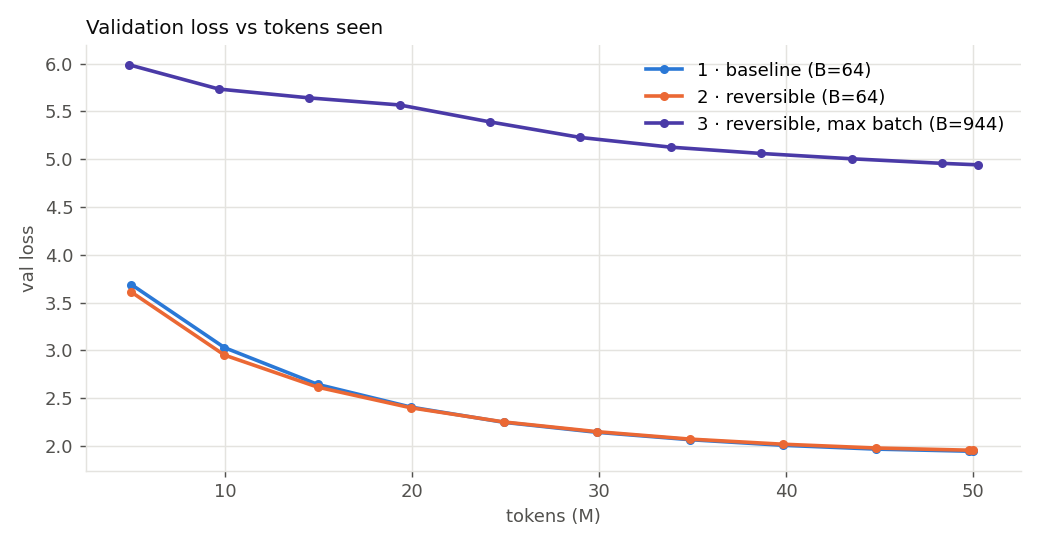

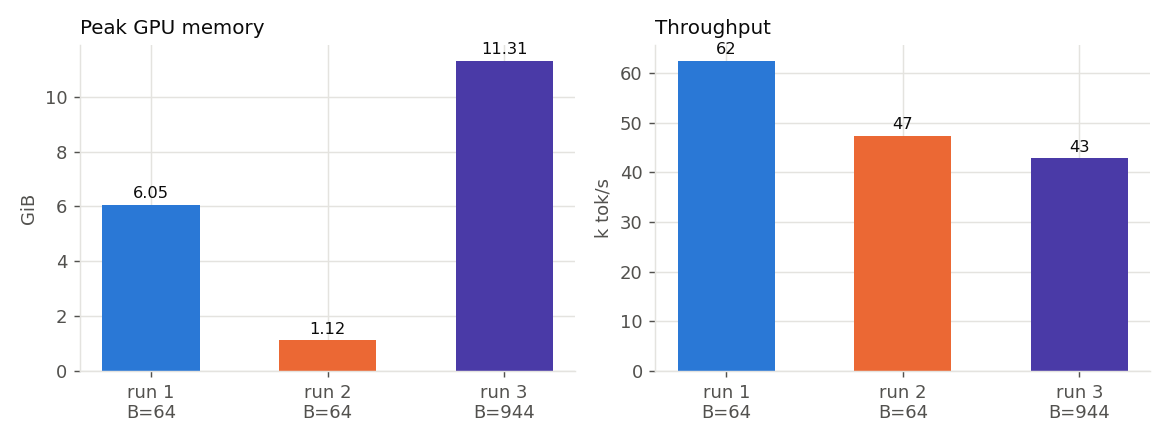



## Which reversible variant worked

Every integrator trained for 5M tokens at batch 64, same seed, same batches.

| mode | exact inverse? | status | final val loss | Δ vs standard | tok/s (steady) | speed vs standard | peak mem | grad cosine (init) | grad cosine (trained) |
|---|---|---|---|---|---|---|---|---|---|
| standard | (no inverse needed) | ok | 4.1126 | +0.0000 | 74,107 | 1.00x | 6.05 GiB | — | — |
| revnet | yes | ok | 4.1297 | +0.0171 | 55,181 | 0.74x | 1.16 GiB | 1.000000 | 0.999847 |
| midpoint | yes | ok | 4.0794 | -0.0332 | 51,018 | 0.69x | 1.12 GiB | 1.000000 | 0.999985 |
| leapfrog | yes | ok | 3.8611 | -0.2515 | 47,566 | 0.64x | 1.12 GiB | 0.999996 | 0.999947 |
| euler | no (fixed point) | ok | 5.7443 | +1.6317 | 22,171 | 0.30x | 1.08 GiB | 0.846343 | 0.009254 |


**Chosen variant: `leapfrog`**. Rule: lowest sweep val loss among variants whose trained-weight gradient cosine vs autograd is ≥ 0.999.

- `revnet`: val 4.1297, 55,181 tok/s
- `midpoint`: val 4.0794, 51,018 tok/s
- `leapfrog`: val 3.8611, 47,566 tok/s
- `euler`: excluded: grad cosine vs autograd (trained weights) 0.0093 < 0.999



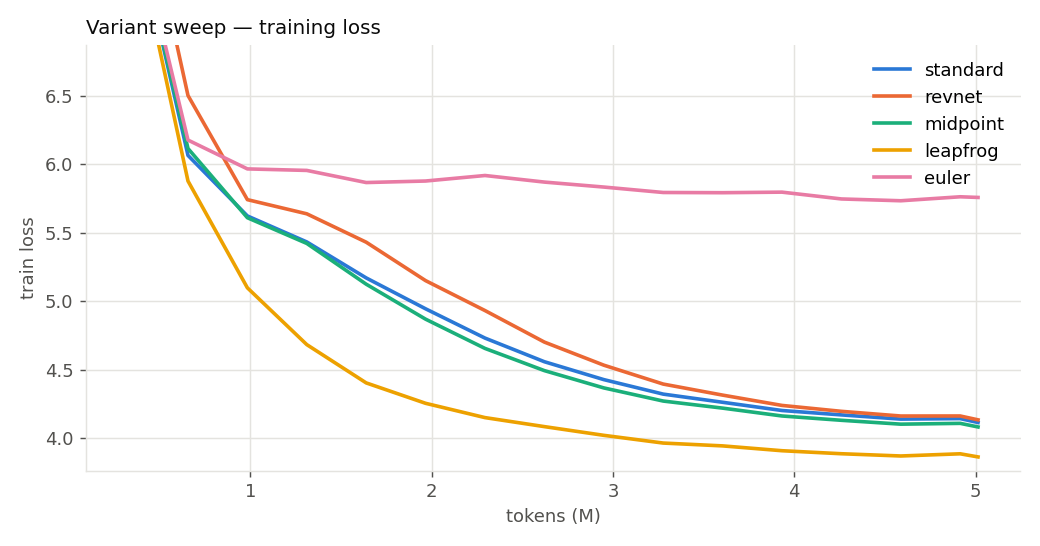



## Maximum batch size that fits

3 real training steps per attempt, seq len 512, GPU memory 14.6 GiB.

| mode | max batch (seqs) | tokens/step | peak at max | tok/s at max |
|---|---|---|---|---|
| standard | 160 | 81,920 | 13.58 GiB | 65,662 |
| ckpt | 896 | 458,752 | 14.22 GiB | 51,494 |
| leapfrog | 1200 | 614,400 | 14.28 GiB | 43,210 |



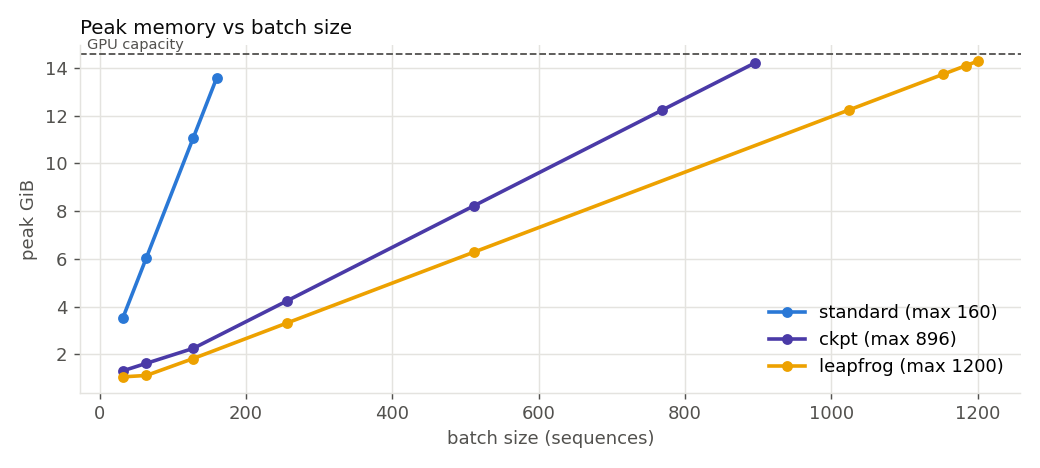



## Samples (prompt: "Once upon a time", T=0.8, top-k 40)

**run1** — Once upon a time there was a little girl named Lily. One day, Lily went to the doctor with her mom many tools. Her mom asked her that she had to go to the doctor.

The doctor said that Lily was a dependable stranger and he would get out of her toys. Lily felt sad because she had no one to play with. Lily's mom explained to her that she needed to rest, so she gave her a hug.

While they were playing, Lily's mom asked her what was wrong. Lily replied, "I lost my toy. I did not have anything to play with."

**run2** — Once upon a time, there was a big lion who loved to eat carrots. One day, he went to the river to find some carrots for his carrots. But there was no one to eat all the carrots.

Suddenly, a little bird saw the lion in the sky. The lion asked the bird, "What's your name?" The bird replied, "My name is Bunny. I am a lion, but I am strong and you can play with me in the forest." The lion wanted to talk to the bird and said, "I am too small. You are a good monkey."

The

**run3** — Once upon a time. They loved was their ground in the go. They " day and a girl the girl she was a new the a't it was a little't friends. He, Timmy it to the time in to not help, had the girl he "Lily was a help a park.

 He would mom!" He went and the lot. She wanted. day.
Ben felt friends,, saw the girl. She's a play.
They the time namedDo his good her a girl was him to his little time and their little lot. They did a time they was the girl named


In [ ]:
from IPython.display import Markdown, Image, display
import re
rep = f"{ROOT}/report"
text = open(f"{rep}/results.md", encoding="utf-8").read()
for part in re.split(r"!\[[^\]]*\]\(([^)]+)\)", text):
    if part.endswith(".png"):
        display(Image(f"{rep}/{part}"))
    elif part.strip():
        display(Markdown(part))

## Download the results
Zips the JSON results and the report (not the data or checkpoints). Bring `s13_results.zip` back to the repo.

In [ ]:
import shutil
from google.colab import files
os.makedirs("/content/s13_results", exist_ok=True)
for f in os.listdir(f"{ROOT}/runs"):
    if f.endswith(".json"):
        shutil.copy(f"{ROOT}/runs/{f}", "/content/s13_results/")
shutil.copytree(f"{ROOT}/runs/sweep", "/content/s13_results/sweep", dirs_exist_ok=True)
shutil.copytree(f"{ROOT}/report", "/content/s13_results/report", dirs_exist_ok=True)
shutil.make_archive("/content/s13_results", "zip", "/content/s13_results")
files.download("/content/s13_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>